# Compression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.fftpack as fft
import skimage.io as io

import matplotlib as mpl
plt.style.use('../bip.mplstyle')
# mpl.rcParams['xtick.bottom'] = False
# mpl.rcParams['ytick.left'] = False
# plt.rcParams['image.cmap'] = 'gray'

## RLE

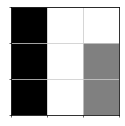

In [2]:
fig = plt.figure(figsize=(2,2))
img = np.array([[0, 255, 255], [0, 255, 128], [0, 255, 128]])
plt.imshow(img, cmap="gray")
ax = plt.gca()
plt.xticks([])
plt.yticks([])
ax.set_xticks(np.arange(-.5,3), minor=True)
ax.set_yticks(np.arange(-.52,3), minor=True)
ax.grid(which='minor', color='#cccccc')
# tick_params(axis='both', labelsize=0, length=0)
plt.grid()

plt.savefig("rle.svg")

## DCT

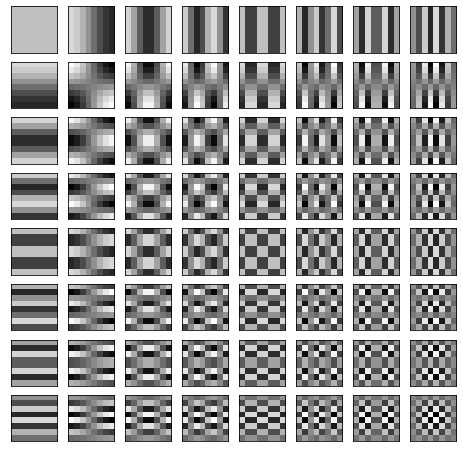

In [3]:
fig = plt.figure(figsize=(8,8))
for x in range(8):
    for y in range(8):
    
        # DCT (nulle partout sauf au pixel p)
        F = np.zeros((8,8))
        F[y,x] = 1

        # DCT inverse (ne pas oublier l'option norm='ortho' !)
        f = fft.idctn(F, norm='ortho')
        
        # Affichage de l'image de la base
        plt.subplot(8, 8, 8*y+x+1)
        plt.imshow(f, "gray", vmin=-.25, vmax=.25)
        plt.xticks([])
        plt.yticks([])
        
plt.savefig("dct-coefficients.svg")

## JPEG

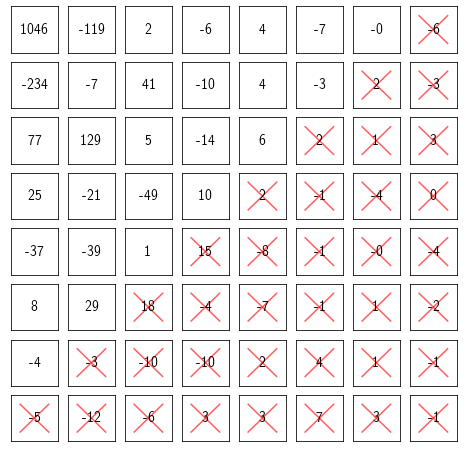

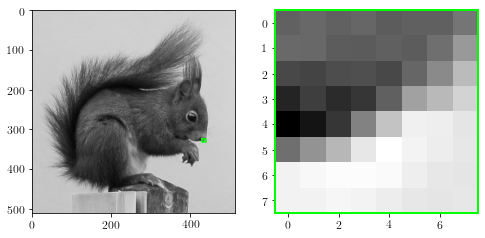

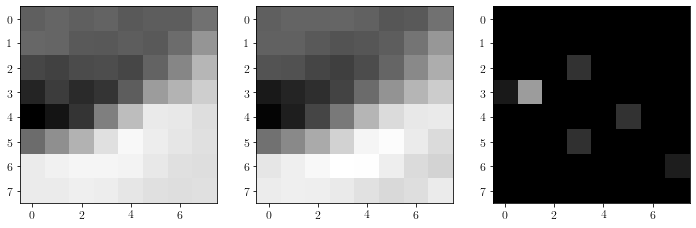

In [18]:
img = io.imread("../figs/squirrel.png")

x1, y1 = 430, 325
x2, y2 = x1+8, y1+8
crop = img[y1:y2, x1:x2]

I = fft.dctn(crop, norm='ortho')
J = I.copy()

# Affichage
fig = plt.figure(figsize=(8,8))
for x in range(8):
    for y in range(8):
        
        plt.subplot(8, 8, 8*y+x+1)
        plt.text(.5, .5, f"{I[y,x]:.0f}", horizontalalignment='center', verticalalignment='center', size=14)
        plt.xticks([])
        plt.yticks([])
        
        if x+y>=7:
            I[y,x]=0
            plt.plot([.2, .8], [.2, .8], color="#ff0000A0")
            plt.plot([.2, .8], [.8, .2], color="#ff0000A0")
            
        plt.xlim([0, 1])
        plt.ylim([0, 1])

# plt.savefig("squirrel-coefficients.svg")

rec = fft.idctn(I, norm='ortho')

# Entire image & crop
fig = plt.figure(figsize=(8,5))
plt.subplot(1,2,1)
plt.imshow(img, "gray")
plt.plot([x1, x1, x2, x2, x1], [y1, y2, y2, y1, y1], color="#00ff00")
crop = img[y1:y2, x1:x2]
ax = plt.subplot(1,2,2)
for pos in ['bottom', 'top', 'left', 'right']:
    ax.spines[pos].set_color('#00ff00')
    ax.spines[pos].set_linewidth(2)
plt.imshow(crop, "gray")

plt.savefig("squirrel-crop.svg")

# Comparison (before and after compression)
fig, axs = plt.subplots(1, 3, figsize=(12,5))
vmin = min(crop.min(), rec.min())
vmax = max(crop.max(), rec.max())
axs[0].imshow(crop, cmap="gray", vmin=vmin, vmax=vmax)
axs[1].imshow(rec, cmap="gray", vmin=vmin, vmax=vmax)
axs[2].imshow((crop-rec)*10, cmap="gray", vmin=vmin, vmax=vmax)

plt.savefig("squirrel-comparison.svg")

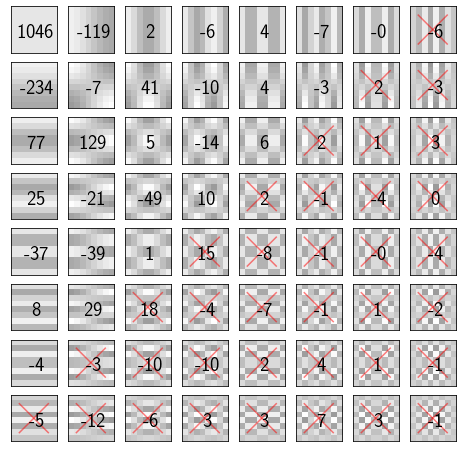

In [5]:
fig = plt.figure(figsize=(8,8))
for x in range(8):
    for y in range(8):
    
        # DCT (nulle partout sauf au pixel p)
        F = np.zeros((8,8))
        F[y,x] = 1

        # DCT inverse (ne pas oublier l'option norm='ortho' !)
        f = fft.idctn(F, norm='ortho')
        
        # Affichage de l'image de la base
        plt.subplot(8, 8, 8*y+x+1)
        plt.imshow(f, "gray", vmin=-1, vmax=.25)
        
        if x+y>=7:
            F[y,x]=0
            plt.plot([1,6], [1,6], color="#ff000080")
            plt.plot([1,6], [6,1], color="#ff000080")
        
        plt.text(4, 4, f"{J[y,x]:.0f}", ha='center', va='center', size=20)
        
        plt.xticks([])
        plt.yticks([])
        
        
plt.savefig("squirrel-coefficients.svg")